In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score , accuracy_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense , Input , Flatten , Dropout
import keras_tuner as kt

In [2]:
df = pd.read_csv(r"D:\datasets\diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
df.corr()["Outcome"]

Pregnancies                 0.221898
Glucose                     0.466581
BloodPressure               0.065068
SkinThickness               0.074752
Insulin                     0.130548
BMI                         0.292695
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
Name: Outcome, dtype: float64

In [5]:
x = df.iloc[: , :-1]
y = df.iloc[: , -1]
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state=1)
x_train.shape

(614, 8)

In [6]:
x_scaler = StandardScaler()

x_train_scaled = x_scaler.fit_transform(x_train)
x_test_scaled = x_scaler.transform(x_test)


# Normal ANN without keras tuner

In [7]:
model = Sequential()

model.add(Input(shape=(x_train.shape[1],)))
model.add(Dense(32 , activation='relu'))
model.add(Dense(1 , activation='sigmoid'))

model.compile(loss = 'binary_crossentropy' , optimizer = 'Adam' , metrics=['accuracy'])

In [8]:
history = model.fit(x_train_scaled , y_train , verbose=1 , validation_split=0.2 , epochs=50 , batch_size=20)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4297 - loss: 0.7553 - val_accuracy: 0.5203 - val_loss: 0.7064
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5703 - loss: 0.6779 - val_accuracy: 0.6341 - val_loss: 0.6433
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6680 - loss: 0.6251 - val_accuracy: 0.7236 - val_loss: 0.5985
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7006 - loss: 0.5876 - val_accuracy: 0.7480 - val_loss: 0.5619
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7352 - loss: 0.5586 - val_accuracy: 0.7724 - val_loss: 0.5337
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7352 - loss: 0.5364 - val_accuracy: 0.7724 - val_loss: 0.5136
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7536 - loss: 0.5187 - val_accuracy: 0.7805 - val_loss: 0.4987
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7556 - loss: 0.5055 - val_accuracy: 0.7724 - val_loss

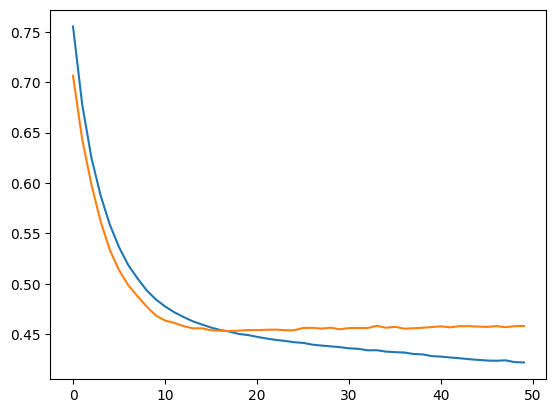

In [9]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.show()

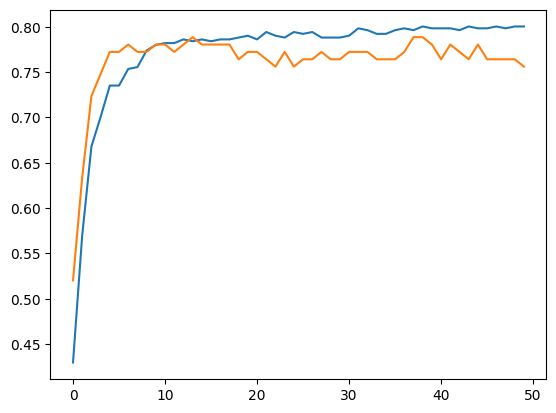

In [10]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.show()

In [11]:
y_prob = model.predict(x_test_scaled)
y_pred = np.where(y_prob > 0.5 , 1 , 0)
accuracy_score(y_test , y_pred)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


0.7922077922077922

# Keras tuner optimizer

In [12]:
def build_model(hp):
    model = Sequential()

    model.add(Input(shape=(x_train.shape[1],)))
    model.add(Dense(32 , activation='relu'))
    model.add(Dense(1 , activation='sigmoid'))

    optimizer = hp.Choice('optimizer' , values = ["SGD" ,"RMSprop" ,"Adam" ,"Adagrad" ,"Adadelta"  ])
    model.compile(loss = 'binary_crossentropy' , optimizer = optimizer , metrics=['accuracy'])
    
    return model

In [13]:
tuner = kt.RandomSearch(build_model , objective='val_accuracy' , max_trials=5)

Reloading Tuner from .\untitled_project\tuner0.json


In [14]:
tuner.search(x_train_scaled , y_train , epochs = 5 , validation_split = 0.2)

In [15]:
tuner.get_best_hyperparameters()[0].values

{'optimizer': 'RMSprop'}

In [16]:
model = tuner.get_best_models(num_models=1)[0]


C:\Users\Anirban Das\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(x_train_scaled , y_train , batch_size = 32, epochs = 100 , initial_epoch=6 , verbose = 1 , validation_split=0.2)

Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7678 - loss: 0.5122 - val_accuracy: 0.7805 - val_loss: 0.4714
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7699 - loss: 0.4996 - val_accuracy: 0.7805 - val_loss: 0.4629
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7800 - loss: 0.4922 - val_accuracy: 0.7805 - val_loss: 0.4572
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7800 - loss: 0.4863 - val_accuracy: 0.7805 - val_loss: 0.4538
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7821 - loss: 0.4813 - val_accuracy: 0.7805 - val_loss: 0.4506
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7821 - loss: 0.4772 - val_accuracy: 0.7886 - val_loss: 0.4477
Epoch 13/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7862 - loss: 0.4736 - val_accuracy: 0.7805 - val_loss: 0.4447
Epoch 14/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7943 - loss: 0.4710 - val_accuracy: 0.7

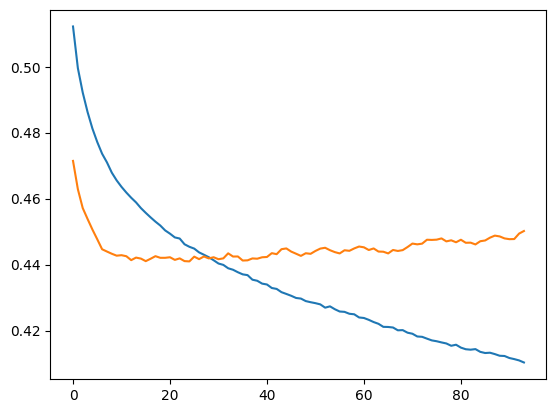

In [19]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.show()

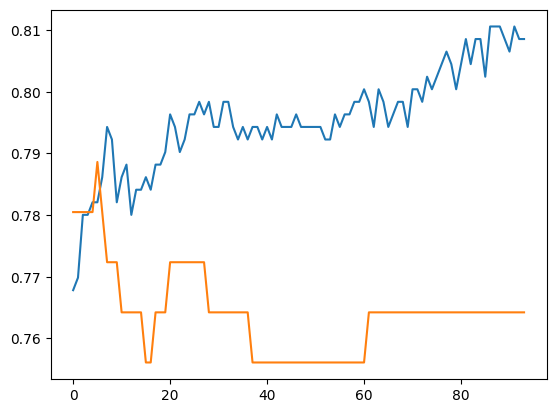

In [20]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.show()

In [21]:
y_prob = model.predict(x_test_scaled)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [22]:
y_pred = np.where(y_prob > 0.5 , 1 , 0)
y_pred

array([[1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
    

In [23]:
accuracy_score(y_test , y_pred)

0.7727272727272727

# Keras tuner for number of node in a layer

In [25]:
def build_model(hp):
    model = Sequential()

    model.add(Input(shape=(x_train.shape[1],)))

    units = hp.Int('units' , min_value = 8 , max_value = 128 , step = 8)
    model.add(Dense(units = units , activation='relu'))
    model.add(Dense(1 , activation='sigmoid'))

    model.compile(loss = 'binary_crossentropy' , optimizer = 'RMSprop' , metrics=['accuracy'])
    
    return model

In [28]:
tuner = kt.RandomSearch(build_model, objective='val_accuracy' , max_trials=5 , directory = 'mydir')

In [29]:
tuner.search(x_train_scaled , y_train , epochs = 5 , validation_data = (x_test_scaled , y_test))

Trial 5 Complete [00h 00m 03s]
val_accuracy: 0.7402597665786743

Best val_accuracy So Far: 0.8116883039474487
Total elapsed time: 00h 00m 15s


In [31]:
tuner.get_best_hyperparameters()[0].values

{'units': 112}

In [33]:
model = tuner.get_best_models(num_models = 1)[0]

C:\Users\Anirban Das\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 112)                 │           1,008 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             113 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history = model.fit(x_train_scaled  , y_train , epochs = 100 , initial_epoch=6 , validation_split=0.2, verbose = 1)

Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7739 - loss: 0.4791 - val_accuracy: 0.7561 - val_loss: 0.4412
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7780 - loss: 0.4694 - val_accuracy: 0.7642 - val_loss: 0.4424
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7760 - loss: 0.4649 - val_accuracy: 0.7561 - val_loss: 0.4419
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7841 - loss: 0.4608 - val_accuracy: 0.7642 - val_loss: 0.4415
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7780 - loss: 0.4580 - val_accuracy: 0.7561 - val_loss: 0.4405
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7800 - loss: 0.4559 - val_accuracy: 0.7642 - val_loss: 0.4410
Epoch 13/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7841 - loss: 0.4535 - val_accuracy: 0.7642 - val_loss: 0.4424
Epoch 14/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7862 - loss: 0.4514 - val_accuracy:

In [39]:
y_prob = model.predict(x_test_scaled)
y_pred = np.where(y_prob > 0.5 , 1 , 0)
accuracy_score(y_test , y_pred)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


0.8051948051948052

# Keras tuner for number of Layers

In [40]:
def build_model(hp):
    model = Sequential()

    model.add(Input(shape=(x_train.shape[1],)))
    model.add(Dense(72 , activation='relu'))

    for i in range(hp.Int('num_layer' , min_value = 1 , max_value = 10)):
        model.add(Dense(72 , activation='relu'))
    
    model.add(Dense(1 , activation='sigmoid'))

    model.compile(loss = 'binary_crossentropy' , optimizer = 'RMSprop' , metrics=['accuracy'])
    
    return model

In [46]:
tuner = kt.RandomSearch(build_model , objective='val_accuracy' , max_trials=5 , directory = 'mydir' , project_name='num_layer')

In [47]:
tuner.search(x_train_scaled , y_train , epochs = 5 , validation_data = (x_test_scaled , y_test))

Trial 5 Complete [00h 00m 04s]
val_accuracy: 0.798701286315918

Best val_accuracy So Far: 0.8181818127632141
Total elapsed time: 00h 00m 20s


In [49]:
tuner.get_best_hyperparameters()[0].values


{'num_layer': 6}

In [50]:
model = tuner.get_best_models(num_models = 1)[0]

C:\Users\Anirban Das\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [51]:
history = model.fit(x_train_scaled  , y_train , epochs = 100 , initial_epoch=6 , validation_split=0.2, verbose = 1)

Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7617 - loss: 0.4730 - val_accuracy: 0.7886 - val_loss: 0.4362
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7800 - loss: 0.4370 - val_accuracy: 0.8049 - val_loss: 0.4404
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7882 - loss: 0.4352 - val_accuracy: 0.7886 - val_loss: 0.4362
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8024 - loss: 0.4241 - val_accuracy: 0.7886 - val_loss: 0.4295
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8086 - loss: 0.4126 - val_accuracy: 0.7642 - val_loss: 0.4651
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8106 - loss: 0.4029 - val_accuracy: 0.7805 - val_loss: 0.4360
Epoch 13/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8391 - loss: 0.3855 - val_accuracy: 0.7724 - val_loss: 0.4512
Epoch 14/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8289 - loss: 0.3890 - val_accuracy: 0.77

In [52]:
y_prob = model.predict(x_test_scaled)
y_pred = np.where(y_prob > 0.5 , 1 , 0)
accuracy_score(y_test , y_pred)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


0.7012987012987013

# keras tuner for hypertune all things

In [59]:
def build_model(hp):
    model = Sequential()

    model.add(Input(shape=(x_train.shape[1],)))

    for i in range(hp.Int('num_layer' , min_value = 1 , max_value = 10)):
        model.add(Dense(
            hp.Int('node' + str(i) , min_value = 8, max_value = 128),
            activation=hp.Choice('activation' + str(i) , values=['relu' , 'tanh' , 'sigmoid' , 'elu' , 'gelu'])))
        model.add(Dropout(hp.Choice('dropout'+str(i) , values=[ 0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9 ])))
        
    model.add(Dense(1 , activation='sigmoid'))

    model.compile(loss = 'binary_crossentropy' , 
                  optimizer = hp.Choice('optimizer' , values=['SGD' , 'RMSprop', 'Adam' , 'Adagrad' , 'Adadelta' ]) ,
                  metrics=['accuracy'])
    
    return model

In [62]:
tuner = kt.RandomSearch(build_model , objective='val_accuracy' , max_trials=10 , directory = 'mydir' , project_name = 'final1')

In [63]:
tuner.search(x_train_scaled , y_train , epochs = 10 , validation_data = (x_test_scaled , y_test))

Trial 10 Complete [00h 00m 06s]
val_accuracy: 0.7857142686843872

Best val_accuracy So Far: 0.7922077775001526
Total elapsed time: 00h 00m 54s


In [64]:
tuner.get_best_hyperparameters()[0].values

{'num_layer': 4,
 'node0': 69,
 'activation0': 'relu',
 'dropout0': 0.6,
 'optimizer': 'RMSprop',
 'node1': 61,
 'activation1': 'elu',
 'dropout1': 0.4,
 'node2': 116,
 'activation2': 'sigmoid',
 'dropout2': 0.3,
 'node3': 93,
 'activation3': 'gelu',
 'dropout3': 0.2,
 'node4': 120,
 'activation4': 'tanh',
 'dropout4': 0.5,
 'node5': 109,
 'activation5': 'relu',
 'dropout5': 0.2,
 'node6': 119,
 'activation6': 'elu',
 'dropout6': 0.3,
 'node7': 50,
 'activation7': 'elu',
 'dropout7': 0.2,
 'node8': 102,
 'activation8': 'elu',
 'dropout8': 0.6}

In [66]:
model = tuner.get_best_models(num_models=1)[0]
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 69)                  │             621 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 69)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 61)                  │           4,270 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 61)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 116)                 │           7,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 116)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 93)                  │          10,881 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 93)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              94 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,058 (90.07 KB)

 Trainable params: 23,058 (90.07 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
history = model.fit(x_train_scaled  , y_train , epochs = 100 , initial_epoch=5 , validation_split=0.2, verbose = 1)

Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7189 - loss: 0.5430 - val_accuracy: 0.7480 - val_loss: 0.4492
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7230 - loss: 0.5259 - val_accuracy: 0.7398 - val_loss: 0.4477
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7291 - loss: 0.5507 - val_accuracy: 0.7642 - val_loss: 0.4450
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7189 - loss: 0.5456 - val_accuracy: 0.7805 - val_loss: 0.4458
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7434 - loss: 0.5020 - val_accuracy: 0.7642 - val_loss: 0.4627
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7332 - loss: 0.5091 - val_accuracy: 0.7805 - val_loss: 0.4325
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7373 - loss: 0.5408 - val_accuracy: 0.7561 - val_loss: 0.4455
Epoch 13/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7352 - loss: 0.5159 - val_accuracy: 0.76

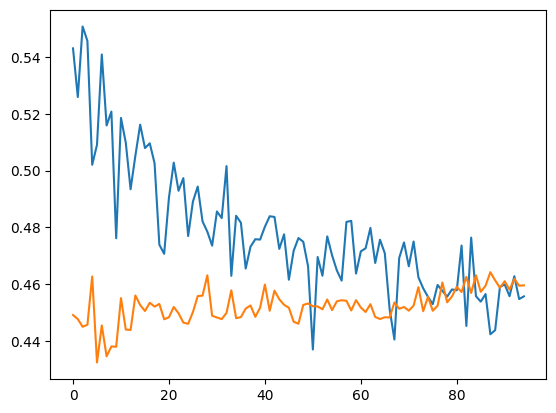

In [68]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.show()

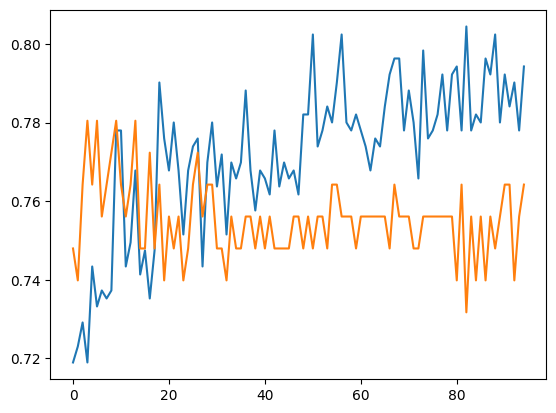

In [69]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.show()

In [70]:
y_prob = model.predict(x_test_scaled)
y_pred = np.where(y_prob > 0.5 , 1 , 0)
accuracy_score(y_test , y_pred)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


0.7922077922077922